In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../datasets/AmesHousing.csv')

In [9]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [17]:
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [22]:
(df.isnull().mean()*100)[df.isnull().sum()>0]

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [23]:
df.shape

(2930, 82)

In [59]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.06 and df[var].isnull().mean() > 0]
cols

['Mas Vnr Area',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Electrical',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage Area',
 'Garage Qual',
 'Garage Cond']

In [60]:
df[cols].sample(5)

,Mas Vnr Area,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Electrical,Bsmt Full Bath,Bsmt Half Bath,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond
2245,473.0,Gd,TA,Gd,GLQ,1573.0,Unf,0.0,0.0,1573.0,SBrkr,1.0,1.0,Attchd,2006.0,Fin,2.0,495.0,TA,TA
258,116.0,Gd,TA,No,GLQ,505.0,Unf,0.0,299.0,804.0,SBrkr,0.0,0.0,Attchd,1998.0,RFn,2.0,523.0,TA,TA
2496,0.0,TA,TA,No,BLQ,465.0,Unf,0.0,447.0,912.0,SBrkr,0.0,0.0,Attchd,1961.0,Unf,1.0,288.0,TA,TA
1882,66.0,TA,TA,No,Unf,0.0,Unf,0.0,1065.0,1065.0,SBrkr,0.0,0.0,Detchd,1974.0,Unf,2.0,461.0,TA,TA
2574,0.0,Fa,TA,Mn,BLQ,623.0,Unf,0.0,556.0,1179.0,SBrkr,0.0,0.0,Attchd,1957.0,RFn,1.0,331.0,TA,TA


In [61]:
(df.isnull().mean()*100)[df.isnull().sum()>0]

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [62]:
len(df[cols].dropna())/len(df)

0.9139931740614334

In [63]:
new_df = df[cols].dropna()

In [64]:
df.shape, new_df.shape

((2930, 82), (2678, 20))

<Axes: >

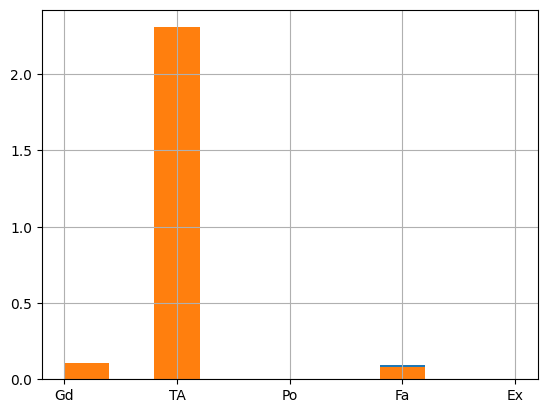

In [65]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['Bsmt Cond'].hist(ax=ax,density=True)
new_df['Bsmt Cond'].hist(ax=ax,density=True)

In [66]:
df['Bsmt Cond'].value_counts()

Bsmt Cond
TA    2616
Gd     122
Fa     104
Po       5
Ex       3
Name: count, dtype: int64

In [67]:

new_df['Bsmt Cond'].value_counts()

Bsmt Cond
TA    2471
Gd     115
Fa      87
Ex       3
Po       2
Name: count, dtype: int64

In [68]:
#For CCA:
# * Numerical columns → compare histograms/KDE plots.
# * Categorical columns → compare value count proportions.

<Axes: >

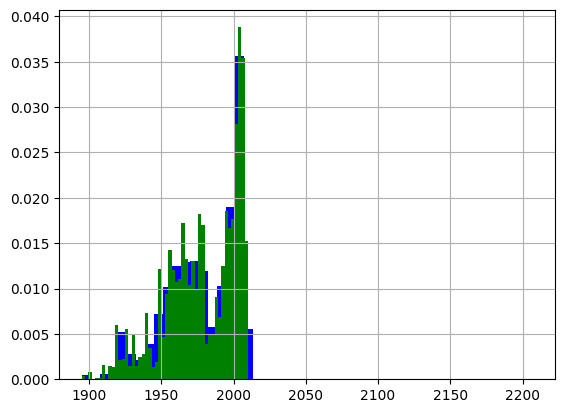

In [91]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['Garage Yr Blt'].hist(bins=50,ax=ax,density=True,color='Blue')
new_df['Garage Yr Blt'].hist(bins=50,ax=ax,density=True,color='Green')

In [78]:
pd.concat([
    df['Garage Yr Blt'].describe(),
    new_df['Garage Yr Blt'].describe()
], axis=1)

,Garage Yr Blt,Garage Yr Blt
count,2771.000000,2678.000000
mean,1978.132443,1978.182972
std,25.528411,25.186761
min,1895.000000,1895.000000
25%,1960.000000,1961.000000
50%,1979.000000,1980.000000
75%,2002.000000,2002.000000
max,2207.000000,2010.000000


In [89]:
pd.concat([
    df['Bsmt Cond'].value_counts()/len(df),
    new_df['Bsmt Cond'].value_counts()/len(new_df)
],axis=1)*100
#Shows percentages of each category in the column, trying to see if the proportion have changes much or not

,count,count
Bsmt Cond,,
TA,89.283276,92.270351
Gd,4.163823,4.294249
Fa,3.549488,3.248693
Po,0.170648,0.074683
Ex,0.102389,0.112024


<Axes: ylabel='Density'>

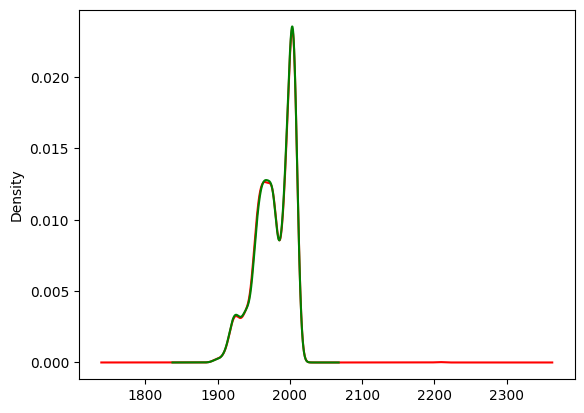

In [92]:
fig = plt.Figure()
ax = fig.add_subplot(111)

df['Garage Yr Blt'].plot.density(color='red')
new_df['Garage Yr Blt'].plot.density(color='green')